### NARX data interpretation

In [1]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

lag = 5
out_dim = 1
units = 32
n_epochs = 150
bs = 64
tol = 5
no_improve = 0

data = np.load(
    "/home/michel/Documents/machineLearningForControl/code/gym-unbalanced-disk-5SC28-group-24/disc-benchmark-files/training-val-test-data.npz"
)
y_raw = data["th"]
u_raw = data["u"]


def build_regressor_matrix(u, y, p):
    # stack lagged inputs and outputs into rows
    # each row: [u(k-p)...u(k-1), y(k-p)...y(k-1)] -> y(k)
    phi, targets = [], []
    for k in range(p, len(y)):
        phi.append(np.concatenate([u[k-p:k], y[k-p:k]]))
        targets.append(y[k])
    return np.array(phi), np.array(targets)

### Normalize data

In [2]:
phi, targets = build_regressor_matrix(u_raw, y_raw, lag)

phi_tv, phi_test, t_tv, t_test = train_test_split(
    phi, targets, test_size=0.3, random_state=24, shuffle=False
)
phi_train, phi_val, t_train, t_val = train_test_split(
    phi_tv, t_tv, test_size=0.35, random_state=24, shuffle=True
)

x_mu  = phi_train.mean(axis=0)
x_sig = phi_train.std(axis=0)
y_mu  = t_train.mean()
y_sig = t_train.std()

phi_train = (phi_train - x_mu) / x_sig
phi_val   = (phi_val - x_mu) / x_sig
phi_test  = (phi_test - x_mu) / x_sig
t_train   = (t_train - y_mu) / y_sig
t_val     = (t_val - y_mu) / y_sig
t_test    = (t_test - y_mu) / y_sig

to_t = lambda a: torch.tensor(a, dtype=torch.float32)
phi_train, phi_val, phi_test = to_t(phi_train), to_t(phi_val), to_t(phi_test)
t_train,   t_val, t_test   = to_t(t_train), to_t(t_val), to_t(t_test)

input_size = phi_train.shape[1]

### simple neural network structure

In [3]:
class MLP(nn.Module):
    def __init__(self, n_in, n_out, n_hidden):
        super().__init__()
        self.fc1 = nn.Linear(n_in, n_hidden).float()
        self.fc2 = nn.Linear(n_hidden, n_hidden).float()
        self.fc3 = nn.Linear(n_hidden, n_out).float()

    def forward(self, x):
        x = torch.sigmoid(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return self.fc3(x)[:, 0]

model = MLP(input_size, out_dim, units)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn  = nn.MSELoss()

### training loop for the simple NN model. Using the normalized NARX data

In [4]:
idx = np.arange(len(phi_train), dtype=int)
best_val   = float("inf")
best_state = None
train_hist, val_hist = [], []

for epoch in range(n_epochs):
    np.random.shuffle(idx)

    model.train()
    for i in range(0, len(phi_train), bs):
        batch = idx[i:i+bs]
        pred = model(phi_train[batch])
        loss = loss_fn(pred, t_train[batch])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        model.eval()
        v_rmse = loss_fn(model(phi_val),   t_val).sqrt()
        t_rmse = loss_fn(model(phi_train), t_train).sqrt()

    print(f"epoch {epoch}  train {t_rmse:.4f}  val {v_rmse:.4f}")

    if v_rmse < best_val:
        best_val = v_rmse
        no_improve = 0
        best_state = model.state_dict()
    else:
        no_improve += 1

    if no_improve >= tol:
        print(f"early stop at epoch {epoch}, best val {best_val:.4f}")
        break

    train_hist.append(t_rmse.item())
    val_hist.append(v_rmse.item())

model.load_state_dict(best_state)

epoch 0  train 0.3545  val 0.3613
epoch 1  train 0.1442  val 0.1495
epoch 2  train 0.1275  val 0.1327
epoch 3  train 0.1136  val 0.1185
epoch 4  train 0.1039  val 0.1085
epoch 5  train 0.0935  val 0.0976
epoch 6  train 0.0852  val 0.0891
epoch 7  train 0.0795  val 0.0830
epoch 8  train 0.0738  val 0.0771
epoch 9  train 0.0702  val 0.0733
epoch 10  train 0.0667  val 0.0696
epoch 11  train 0.0618  val 0.0645
epoch 12  train 0.0576  val 0.0602
epoch 13  train 0.0542  val 0.0566
epoch 14  train 0.0514  val 0.0538
epoch 15  train 0.0479  val 0.0501
epoch 16  train 0.0432  val 0.0453
epoch 17  train 0.0410  val 0.0430
epoch 18  train 0.0375  val 0.0392
epoch 19  train 0.0337  val 0.0352
epoch 20  train 0.0314  val 0.0329
epoch 21  train 0.0290  val 0.0303
epoch 22  train 0.0238  val 0.0252
epoch 23  train 0.0222  val 0.0232
epoch 24  train 0.0207  val 0.0216
epoch 25  train 0.0193  val 0.0202
epoch 26  train 0.0184  val 0.0191
epoch 27  train 0.0173  val 0.0180
epoch 28  train 0.0165  val 0.

<All keys matched successfully>

### Evuation of the model using test data split

RMS:  0.0061 rad  /  0.3518 deg
NRMS: 1.22%


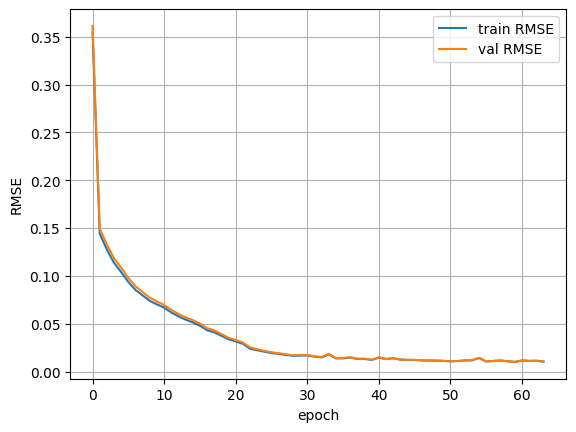

In [5]:
model.eval()
with torch.no_grad():
    pred_norm = model(phi_test).numpy()

pred_real = pred_norm * y_sig + y_mu
true_real = t_test.numpy() * y_sig + y_mu

rms = np.mean((pred_real - true_real)**2)**0.5
print(f"RMS:  {rms:.4f} rad  /  {rms/(2*np.pi)*360:.4f} deg")
print(f"NRMS: {rms/np.std(true_real)*100:.2f}%")

plt.plot(train_hist, label="train RMSE")
plt.plot(val_hist, label="val RMSE")
plt.xlabel("epoch"); plt.ylabel("RMSE"); plt.legend(); plt.grid(); plt.show()

### simulation of the model to predict outcomes

sim RMS:  0.1803 rad  /  10.3319 deg
sim NRMS: 37.62%


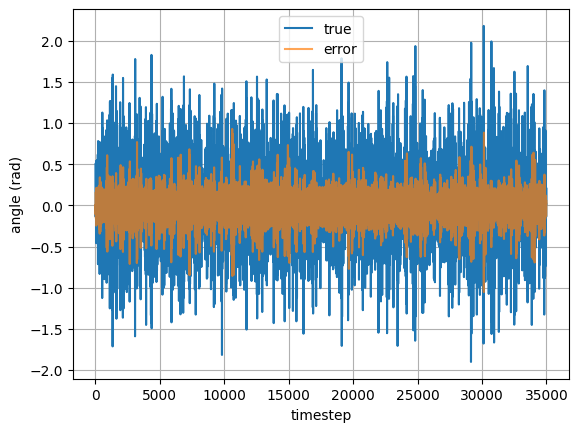

In [6]:
def simulate(f, u, y, skip=50, p=5, x_mu=None, x_sig=None, y_mu=None, y_sig=None):
    upast = u[skip-p:skip].tolist()
    ypast = y[skip-p:skip].tolist()
    out   = y[:skip].tolist()

    f.eval()
    for k in range(skip, len(u)):
        x  = np.concatenate([upast, ypast])
        xt = torch.tensor((x - x_mu) / x_sig, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            yp = f(xt).item() * y_sig + y_mu
        out.append(yp)
        upast.append(u[k]); upast.pop(0)
        ypast.append(yp);   ypast.pop(0)

    return np.array(out)

sim = simulate(model, u_raw, y_raw, skip=lag, p=lag,
               x_mu=x_mu, x_sig=x_sig, y_mu=y_mu, y_sig=y_sig)

err     = sim[lag:] - y_raw[lag:]
rms_sim = np.mean(err**2)**0.5
print(f"sim RMS:  {rms_sim:.4f} rad  /  {rms_sim/(2*np.pi)*360:.4f} deg")
print(f"sim NRMS: {rms_sim/np.std(y_raw[lag:])*100:.2f}%")

plt.plot(y_raw, label="true")
plt.plot(sim - y_raw, label="error", alpha=0.7)
plt.xlabel("timestep"); plt.ylabel("angle (rad)"); plt.legend(); plt.grid(); plt.show()